# Modelo de targeting de SHM con SHazaM

SHazaM permite construir modelos de *targeting* de hipermutación somática (SHM) a partir de secuencias clonales previamente definidas mediante Change-O. Estos modelos estiman patrones de mutabilidad asociados al contexto nucleotídico de las mutaciones.

## Flujo del análisis

1. **Carga del repertorio**
   
   Se carga la tabla `clone-pass.tsv` con las secuencias clonales, alineamientos germinales e información génica necesaria para el análisis.

2. **Preparación y colapso clonal**
   
   Los clones definidos previamente mediante Change-O son colapsados utilizando `collapseClones()`, generando una secuencia consenso representativa para cada clon.

3. **Construcción del modelo de targeting**
   
   A partir de las secuencias consenso clonales se genera un modelo de targeting de SHM mediante `createTargetingModel()`, considerando los patrones de mutaciones silenciosas.

4. **Visualización del modelo**
   
   El patrón de mutabilidad obtenido se representa mediante `plotMutability()`, permitiendo evaluar la preferencia de mutación según el contexto de secuencia.

5. **Cálculo de distancia entre modelos**
   
   Finalmente, se calcula una matriz de distancia mediante `calcTargetingDistance()`, la cual permite comparar la similitud de los perfiles de targeting entre diferentes repertorios o escenarios simulados.

6. **Salida del análisis**
   
   El flujo genera como resultados:
   
   - Modelo de targeting de SHM.
   - Gráfico de mutabilidad.
   - Matriz de distancias entre modelos para análisis comparativo.

In [95]:
library(shazam)
library(alakazam)
library(readr)
library(dplyr)
library(ggplot2)

Secuencias originales: 6398 
Secuencias para SHazaM: 6397 
NA germline: 0 
Vac<U+00ED>as germline: 0 


Warning message in createMutabilityMatrix(db, sub_mat, model = model, sequenceColumn = sequenceColumn, :
"Insufficient number of mutations to infer some 5-mers. Filled with 0. "
Pipeline ejecutado correctamente. Modelo de targeting disponible.

Warning message:
"Removed 256 rows containing missing values or values outside the scale range
(`geom_segment()`)."


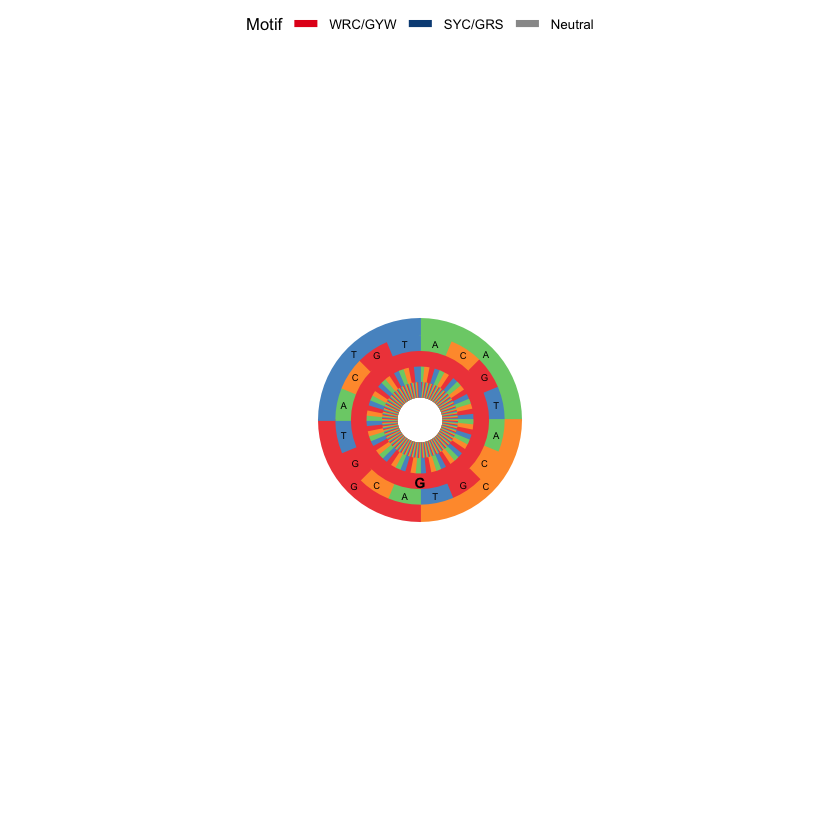

In [ ]:


# 1. Cargar archivo
archivo_clones <- "../data/output/repertorio_D_insilico_6400_seqs_clone-pass.tsv"

db <- read_tsv(archivo_clones, show_col_types = FALSE) %>%
  mutate(
    sample_id = "repertorio_D",
    clone_id = as.character(clone_id)
  ) %>%
  filter(!is.na(clone_id))

# 2. Asignar IGHM si c_call está completamente vacío
if (all(is.na(db$c_call))) {
  db$c_call <- "IGHM"
}

# 3. Filtrar secuencias sin germline válida
db_shazam <- db %>%
  filter(
    !is.na(germline_alignment),
    germline_alignment != ""
  )

# 4. Comprobar cuántas quedaron
cat("Secuencias originales:", nrow(db), "\n")
cat("Secuencias para SHazaM:", nrow(db_shazam), "\n")
cat("NA germline:", sum(is.na(db_shazam$germline_alignment)), "\n")
cat("Vacías germline:", sum(db_shazam$germline_alignment == ""), "\n")

# 5. Colapsar clones
clones <- collapseClones(
  db_shazam,
  cloneColumn = "clone_id",
  sequenceColumn = "sequence_alignment",
  germlineColumn = "germline_alignment",
  regionDefinition = IMGT_V,
  method = "thresholdedFreq",
  minimumFrequency = 0.6,
 
  nproc = 1
)

# 6. Modelo de targeting
targeting_model <- createTargetingModel(
  clones,
  model = "s",
  sequenceColumn = "clonal_sequence",
  germlineColumn = "clonal_germline",
  vCallColumn = "v_call"
)

# 7. Resultado
if (is.null(targeting_model) || length(targeting_model) == 0) {
  message("Pipeline ejecutado correctamente. No se generó modelo de targeting (no hay mutaciones suficientes).")
} else {
  message("Pipeline ejecutado correctamente. Modelo de targeting disponible.")

  plotMutability(
    targeting_model,
    nucleotides = "G",
    style = "hedgehog"
  )

#targeting_dist <- calcTargetingDistance(targeting_model)
}

In [ ]:
png("../results/shm_models/targeting/repertorio_D_6400seq_targeting_C.png",
    width = 2000,
    height = 1500,
    res = 300)

plotMutability(
  targeting_model,
  nucleotides = "C",
  style = "hedgehog"
)

dev.off()




Warning message:
"Removed 256 rows containing missing values or values outside the scale range
(`geom_segment()`)."


pdf 
  2